# 28 -- Complex (C) Number Probe: The Matrix vs Rumble in the Bronx

Companion to Section 01b's D probe. Same two movies, same `a = (rating - 0.5) / 4.5` encoding, but this time the second coordinate comes from **when** the rating was given, not **how many people** rated the movie.

C encoding: `theta = 2*pi * weekday / 7` (Monday=0 ... Sunday=6), `z = a * exp(i*theta)` -> `z_re = a*cos(theta)`, `z_im = a*sin(theta)`.

Question: R sees `a=0.7778` for both movies (identical). D sees popularity (977 vs 426 ratings). What, if anything, does C see?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
data_dir = root / "data"
out_dir = root / "outputs"
out_dir.mkdir(exist_ok=True)

DENSE_PATH = data_dir / "dense_subset_1000x1000.csv"
print(f"loading {DENSE_PATH}")
dense = pd.read_csv(DENSE_PATH, parse_dates=["timestamp"])

MATRIX, RUMBLE = 2571, 112
MOVIE_NAMES = {MATRIX: "The Matrix (1999)", RUMBLE: "Rumble in the Bronx (1995)"}

sub = dense[dense["movieId"].isin([MATRIX, RUMBLE])].copy()
print(f"{len(sub)} rating rows for the two movies "
      f"(Matrix={len(sub[sub.movieId==MATRIX])}, Rumble={len(sub[sub.movieId==RUMBLE])})")

loading /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/dense_subset_1000x1000.csv


1403 rating rows for the two movies (Matrix=977, Rumble=426)


## Step 1: C encoding

`a` from the rating value, `theta` from the weekday of the rating's timestamp.

In [2]:
sub["a"] = (sub["rating"] - 0.5) / 4.5
sub["weekday"] = sub["timestamp"].dt.weekday  # Monday=0 ... Sunday=6
sub["theta"] = 2 * np.pi * sub["weekday"] / 7
sub["z_re"] = sub["a"] * np.cos(sub["theta"])
sub["z_im"] = sub["a"] * np.sin(sub["theta"])

sub[["movieId", "rating", "timestamp", "weekday", "a", "theta", "z_re", "z_im"]].head(8)

,movieId,rating,timestamp,weekday,a,theta,z_re,z_im
23,112,3.0,2002-12-27 22:54:34,4,0.555556,3.590392,-0.500538,-0.241047
370,2571,5.0,2002-12-27 22:29:06,4,1.000000,3.590392,-0.900969,-0.433884
877,2571,3.0,1999-11-08 20:21:53,0,0.555556,0.000000,0.555556,0.000000
1382,2571,3.0,2004-08-29 08:33:38,6,0.555556,5.385587,0.346383,-0.434351
1667,112,4.0,2008-01-21 01:34:13,0,0.777778,0.000000,0.777778,0.000000
1903,2571,5.0,2000-01-14 02:35:40,4,1.000000,3.590392,-0.900969,-0.433884
2325,2571,4.0,2011-12-19 03:13:05,0,0.777778,0.000000,0.777778,0.000000
2649,112,3.5,2005-03-22 08:14:50,1,0.666667,0.897598,0.415660,0.521221


## Step 2: weekday distribution within each movie's rating=4.0 subset, and the representative point

In [3]:
WEEKDAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

rows = []
representative = {}
for mid in (MATRIX, RUMBLE):
    at4 = sub[(sub.movieId == mid) & (sub.rating == 4.0)]
    n = len(at4)
    counts = at4["weekday"].value_counts().reindex(range(7), fill_value=0)
    mode_wd = int(counts.idxmax())
    mode_theta = 2 * np.pi * mode_wd / 7
    a4 = (4.0 - 0.5) / 4.5
    rep = {
        "movie": MOVIE_NAMES[mid], "n_at_4.0": n,
        "mode_weekday": WEEKDAY_NAMES[mode_wd], "mode_count": int(counts.loc[mode_wd]),
        "mode_pct": round(counts.loc[mode_wd] / n * 100, 1) if n else 0.0,
        "theta": round(mode_theta, 4), "z_re": round(a4 * np.cos(mode_theta), 4),
        "z_im": round(a4 * np.sin(mode_theta), 4),
    }
    representative[mid] = rep
    for wd in range(7):
        rows.append({
            "movie": MOVIE_NAMES[mid], "weekday": WEEKDAY_NAMES[wd],
            "count": int(counts.loc[wd]), "pct": round(counts.loc[wd] / n * 100, 1) if n else 0.0,
        })

weekday_table = pd.DataFrame(rows)
weekday_pivot = weekday_table.pivot(index="weekday", columns="movie", values="pct").reindex(WEEKDAY_NAMES)
print(weekday_pivot)
print()
for mid, rep in representative.items():
    print(rep)

movie      Rumble in the Bronx (1995)  The Matrix (1999)
weekday                                                 
Monday                           22.5               14.7
Tuesday                          21.6               14.3
Wednesday                        12.7               15.1
Thursday                         12.7               10.1
Friday                            8.8               14.3
Saturday                         15.7               16.0
Sunday                            5.9               15.5

{'movie': 'The Matrix (1999)', 'n_at_4.0': 238, 'mode_weekday': 'Saturday', 'mode_count': 38, 'mode_pct': np.float64(16.0), 'theta': 4.488, 'z_re': np.float64(-0.1731), 'z_im': np.float64(-0.7583)}
{'movie': 'Rumble in the Bronx (1995)', 'n_at_4.0': 102, 'mode_weekday': 'Monday', 'mode_count': 23, 'mode_pct': np.float64(22.5), 'theta': 0.0, 'z_re': np.float64(0.7778), 'z_im': np.float64(0.0)}


## Step 3: complex-plane scatter -- all ratings, both movies

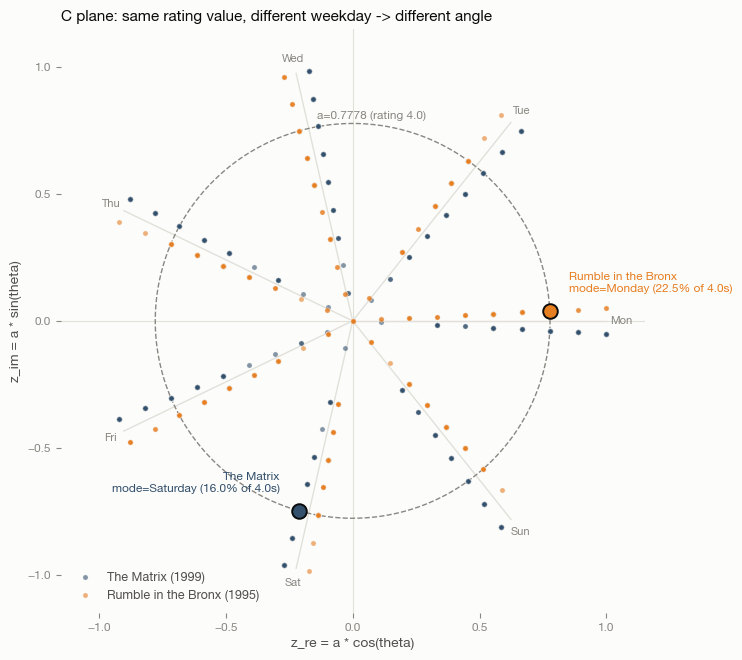

saved /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/complex_probe_matrix_vs_rumble.png


In [4]:
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE = "#33506c", "#e67e22"
plt.rcParams["font.family"] = ["Helvetica Neue", "Arial", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(7.5, 7.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for wd in range(7):
    theta = 2 * np.pi * wd / 7
    ax.plot([0, np.cos(theta)], [0, np.sin(theta)], color=GRID, linewidth=1, zorder=1)
    ax.text(1.06*np.cos(theta), 1.06*np.sin(theta), WEEKDAY_NAMES[wd][:3], color=INK_MUTED,
            fontsize=8, ha="center", va="center")

a4 = (4.0 - 0.5) / 4.5
circle_theta = np.linspace(0, 2*np.pi, 200)
ax.plot(a4*np.cos(circle_theta), a4*np.sin(circle_theta), linestyle="--", color=INK_MUTED, linewidth=1, zorder=1)
ax.text(a4*np.cos(np.pi/2 + 0.18), a4*np.sin(np.pi/2 + 0.18) + 0.03, f"a={a4:.4f} (rating 4.0)",
        color=INK_MUTED, fontsize=8.5, ha="left")

JITTER = 0.05
for mid, color, jitter_dir in [(MATRIX, BLUE, -1), (RUMBLE, ORANGE, +1)]:
    m = sub[sub.movieId == mid]
    theta_jittered = m["theta"] + jitter_dir * JITTER
    x = m["a"] * np.cos(theta_jittered)
    y = m["a"] * np.sin(theta_jittered)
    ax.scatter(x, y, s=14, color=color, alpha=0.6, edgecolors=SURFACE, linewidths=0.3, zorder=3, label=MOVIE_NAMES[mid])

    rep = representative[mid]
    rep_theta = rep["theta"] + jitter_dir * JITTER
    rep_x, rep_y = a4 * np.cos(rep_theta), a4 * np.sin(rep_theta)
    ax.scatter([rep_x], [rep_y], s=110, facecolors=color, edgecolors=INK_PRIMARY, linewidths=1.4, zorder=4)

    short_name = MOVIE_NAMES[mid].split(" (")[0]
    label = f"{short_name}\nmode={rep['mode_weekday']} ({rep['mode_pct']}% of 4.0s)"
    ax.annotate(label, (rep_x, rep_y), textcoords="offset points",
                xytext=(14 if rep_x >= 0 else -14, 14), fontsize=8.5, color=color,
                ha="left" if rep_x >= 0 else "right", fontweight="bold")

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect("equal")
ax.axhline(0, color=GRID, linewidth=0.8, zorder=0)
ax.axvline(0, color=GRID, linewidth=0.8, zorder=0)
ax.set_xlabel("z_re = a * cos(theta)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("z_im = a * sin(theta)", color=INK_SECONDARY, fontsize=10)
ax.set_title("C plane: same rating value, different weekday -> different angle", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="lower left", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(colors=INK_MUTED, labelsize=8.5)

plt.tight_layout()
out_path = out_dir / "complex_probe_matrix_vs_rumble.png"
plt.savefig(out_path, dpi=180, facecolor=SURFACE, bbox_inches="tight")
plt.show()
print(f"saved {out_path}")


## Step 4: what does C actually reveal -- honest comparison

In [5]:
print("R sees: a = 0.7778 for both movies at rating=4.0. Identical, no separation.")
print("D sees: popularity. Matrix b=+1.0 (rank 1, 977 ratings) vs Rumble b=-1.0 (rank 1000, 426 ratings).")
print()
print("C sees: the weekday distribution of when rating=4.0 was actually given. Real counts:")
print(weekday_pivot.to_string())
print()
for mid, rep in representative.items():
    print(f"{MOVIE_NAMES[mid]}: mode weekday = {rep['mode_weekday']} ({rep['mode_pct']}% of {rep['n_at_4.0']} rating=4.0 events)")

weekend = {0,1,2,3,4}  # Mon-Fri = weekday, Sat/Sun = weekend, using weekday() convention 5,6=weekend
def weekday_vs_weekend(mid):
    at4 = sub[(sub.movieId == mid) & (sub.rating == 4.0)]
    is_weekend = at4["weekday"].isin([5, 6])
    return is_weekend.mean() * 100

wm = weekday_vs_weekend(MATRIX)
wr = weekday_vs_weekend(RUMBLE)
print()
print(f"Share of rating=4.0 events falling on a weekend: Matrix {wm:.1f}%  Rumble {wr:.1f}%")
print(f"Difference: {abs(wm-wr):.1f} percentage points")

R sees: a = 0.7778 for both movies at rating=4.0. Identical, no separation.
D sees: popularity. Matrix b=+1.0 (rank 1, 977 ratings) vs Rumble b=-1.0 (rank 1000, 426 ratings).

C sees: the weekday distribution of when rating=4.0 was actually given. Real counts:
movie      Rumble in the Bronx (1995)  The Matrix (1999)
weekday                                                 
Monday                           22.5               14.7
Tuesday                          21.6               14.3
Wednesday                        12.7               15.1
Thursday                         12.7               10.1
Friday                            8.8               14.3
Saturday                         15.7               16.0
Sunday                            5.9               15.5

The Matrix (1999): mode weekday = Saturday (16.0% of 238 rating=4.0 events)
Rumble in the Bronx (1995): mode weekday = Monday (22.5% of 102 rating=4.0 events)

Share of rating=4.0 events falling on a weekend: Matrix 31.5%  Ru

## Step 5: movie x rating x weekday cross-tab, for the interactive web probe

Every (movie, rating level, weekday) count in the subset, so the webpage's C card can compute the mode weekday and its share for whatever rating the user drags the slider to -- not just rating=4.0.

In [6]:
import json

RATING_LEVELS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

crosstab = {}
for mid, key in [(MATRIX, "matrix"), (RUMBLE, "rumble")]:
    m = sub[sub.movieId == mid]
    counts_by_rating = {}
    for r in RATING_LEVELS:
        at_r = m[m.rating == r]
        wd_counts = at_r["weekday"].value_counts().reindex(range(7), fill_value=0).tolist()
        counts_by_rating[f"{r:.1f}"] = wd_counts
    crosstab[key] = counts_by_rating

crosstab_json = json.dumps(crosstab, separators=(",", ":"))
print(crosstab_json)

crosstab_path = out_dir / "complex_probe_crosstab.json"
crosstab_path.write_text(crosstab_json)
print(f"\nsaved {crosstab_path}  ({len(crosstab_json)} chars)")

total_check = sum(sum(v) for m in crosstab.values() for v in m.values())
print(f"sanity check: total counts across crosstab = {total_check} (should equal {len(sub)})")

{"matrix":{"0.5":[1,1,3,0,0,0,0],"1.0":[1,1,2,1,1,1,0],"1.5":[0,2,1,1,2,0,0],"2.0":[5,5,3,6,1,5,8],"2.5":[2,6,4,1,1,1,3],"3.0":[11,17,15,16,16,10,13],"3.5":[12,12,10,12,9,12,12],"4.0":[35,34,36,24,34,38,37],"4.5":[23,30,24,20,25,18,31],"5.0":[44,69,41,47,39,40,42]},"rumble":{"0.5":[1,1,1,1,0,0,2],"1.0":[2,2,2,2,4,0,4],"1.5":[4,0,2,1,1,0,1],"2.0":[3,9,7,3,6,6,12],"2.5":[4,2,2,6,4,5,6],"3.0":[23,20,23,17,19,17,18],"3.5":[9,14,7,10,7,4,7],"4.0":[23,22,13,13,9,16,6],"4.5":[2,1,3,1,2,1,1],"5.0":[2,1,3,1,4,1,0]}}

saved /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/complex_probe_crosstab.json  (512 chars)
sanity check: total counts across crosstab = 1403 (should equal 1403)
